**ФИО:** Комиссаров Антон Сергеевич

**Группа:** М8О-209СВ-24

**data_train.csv** — минутные измерения 16 показателей телеметрии за 8 месяцев для обучения

**target_train.csv** — лабораторные замеры концентрации целевого продукта (нерегулярные, с задержкой 10-15 мин)

**data_test_small.csv**, **target_test_small.csv** — аналогичные данные для тестирования

# 1 | Разведочный анализ данных (EDA)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, kstest

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DATA_TRAIN_PATH = 'data_train.csv'
TARGET_TRAIN_PATH = 'target_train.csv'
DATA_TEST_PATH = 'data_test_small.csv'
TARGET_TEST_PATH = 'target_test_small.csv'

Проведём первичный анализ:

In [2]:
telemetry_raw = pd.read_csv(DATA_TRAIN_PATH)
target_raw = pd.read_csv(TARGET_TRAIN_PATH)

telemetry_raw['datetime'] = pd.to_datetime(telemetry_raw['datetime'])
target_raw['Дата'] = pd.to_datetime(target_raw['Дата'])

strings = [
    "[Телеметрия]",
    f"Общее количество записей: {len(telemetry_raw):,}",
    f"Уникальные временные метки: {telemetry_raw['datetime'].nunique():,}",
    f"Дубликаты по времени: {telemetry_raw.duplicated('datetime').sum():,}",
    f"Период: {telemetry_raw['datetime'].min().date()} — {telemetry_raw['datetime'].max().date()}",
    f"Длительность: {(telemetry_raw['datetime'].max() - telemetry_raw['datetime'].min()).days} дн.",
    "\n[Целевая переменная]",
    f"Всего замеров: {len(target_raw):,}",
    f"Период: {target_raw['Дата'].min().date()} — {target_raw['Дата'].max().date()}",
    f"Среднее: {target_raw['target'].mean():.4f}",
    f"Стд. отклонение: {target_raw['target'].std():.4f}",
    f"Диапазон: [{target_raw['target'].min():.4f}, {target_raw['target'].max():.4f}]",
    "=" * 80
]

print("\n".join(strings))
telemetry_raw.info()

[Телеметрия]
Общее количество записей: 319,546
Уникальные временные метки: 317,998
Дубликаты по времени: 1,548
Период: 2019-03-01 — 2019-10-07
Длительность: 220 дн.

[Целевая переменная]
Всего замеров: 1,773
Период: 2019-03-13 — 2019-10-07
Среднее: 0.2543
Стд. отклонение: 0.0922
Диапазон: [0.0000, 0.7165]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319546 entries, 0 to 319545
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   datetime      319546 non-null  datetime64[ns]
 1   telemetry_0   319529 non-null  float64       
 2   telemetry_1   319530 non-null  float64       
 3   telemetry_2   319530 non-null  float64       
 4   telemetry_3   319530 non-null  float64       
 5   telemetry_4   319413 non-null  float64       
 6   telemetry_5   319529 non-null  float64       
 7   telemetry_6   319530 non-null  float64       
 8   telemetry_7   319530 non-null  float64       
 9   telemetry_8   31

Проведём анализ пропусков:

In [3]:
# Порог для удаления признаков с большим количеством пропусков
DROP_COL_MISSING_RATIO_THRESHOLD = 0.95

# Агрегация дубликатов по времени (усреднение)
telemetry_raw = (
    telemetry_raw
    .groupby('datetime', as_index=False)
    .mean(numeric_only=True)
    .sort_values('datetime')
    .set_index('datetime')
)

# Выделение телеметрических колонок
telemetry_cols = [c for c in telemetry_raw.columns if c.startswith('telemetry_')]

# Расчет статистики пропусков
missing_stats = telemetry_raw[telemetry_cols].isna().sum()
total_rows = len(telemetry_raw)
missing_ratio = (missing_stats / total_rows * 100).sort_values(ascending=False)

# Формирование таблицы для вывода
missing_df = pd.DataFrame({
    'Канал': missing_ratio.index.tolist(),
    'Пропущено (шт)': missing_stats.loc[missing_ratio.index].values,
    'Доля пропусков (%)': missing_ratio.values
})

print(f"\nСтатистика пропусков по каналам (всего: {len(telemetry_cols)}):")
print(missing_df.to_string(index=False))

# Фильтрация каналов по порогу пропусков
threshold = DROP_COL_MISSING_RATIO_THRESHOLD * 100  # конвертация в проценты
keep_mask = missing_ratio <= (DROP_COL_MISSING_RATIO_THRESHOLD * 100)
keep_cols = keep_mask[keep_mask].index.tolist()
dropped_cols = [c for c in telemetry_cols if c not in keep_cols]

print(f"\nРезультаты фильтрации (порог: {DROP_COL_MISSING_RATIO_THRESHOLD*100:.1f}%):")
print(f"\tОставлено каналов: {len(keep_cols)}")
print(f"\tУдалено каналов: {len(dropped_cols)}")
if dropped_cols:
    print(f"\tИсключенные: {', '.join(dropped_cols)}")

# Применение фильтрации
telemetry_raw = telemetry_raw[keep_cols].copy()

# Интерполяция пропусков
telemetry_raw = telemetry_raw.interpolate(method='time', limit_direction='both')
telemetry_raw = telemetry_raw.ffill().bfill()

print(f"Оставшиеся пропуски после интерполяции: {int(telemetry_raw.isna().sum().sum())}")


Статистика пропусков по каналам (всего: 16):
       Канал  Пропущено (шт)  Доля пропусков (%)
telemetry_12          315901           99.340562
telemetry_13          315901           99.340562
telemetry_14          315901           99.340562
telemetry_15          315901           99.340562
 telemetry_4             133            0.041824
 telemetry_0              17            0.005346
 telemetry_5              17            0.005346
 telemetry_1              16            0.005031
 telemetry_7              16            0.005031
 telemetry_6              16            0.005031
 telemetry_2              16            0.005031
 telemetry_3              16            0.005031
telemetry_11              16            0.005031
telemetry_10              16            0.005031
 telemetry_9              16            0.005031
 telemetry_8              16            0.005031

Результаты фильтрации (порог: 95.0%):
	Оставлено каналов: 12
	Удалено каналов: 4
	Исключенные: telemetry_12, telemetry_1

Проведём анализ выбросов:

In [4]:
# Обработка выбросов методом винсоризации
q_low, q_high = 0.01, 0.99
outlier_data = []

for col in telemetry_raw.columns:
    lo = telemetry_raw[col].quantile(q_low)
    hi = telemetry_raw[col].quantile(q_high)

    outliers_count = ((telemetry_raw[col] < lo) | (telemetry_raw[col] > hi)).sum()
    outliers_pct = (outliers_count / len(telemetry_raw)) * 100

    outlier_data.append({
        'Канал': col,
        'Выбросов (шт)': int(outliers_count),
        'Доля (%)': round(outliers_pct, 2)
    })

    telemetry_raw[col] = telemetry_raw[col].clip(lo, hi)

outlier_df = pd.DataFrame(outlier_data).sort_values('Выбросов (шт)', ascending=False)
print(f"\nСтатистика выбросов до обработки (квантили {q_low}-{q_high}):")
print(outlier_df.to_string(index=False))


Статистика выбросов до обработки (квантили 0.01-0.99):
       Канал  Выбросов (шт)  Доля (%)
 telemetry_5           6293      1.98
 telemetry_8           6259      1.97
 telemetry_2           6166      1.94
 telemetry_0           6037      1.90
 telemetry_3           3180      1.00
 telemetry_1           3180      1.00
 telemetry_9           3128      0.98
 telemetry_7           3058      0.96
telemetry_10           2711      0.85
telemetry_11           2317      0.73
 telemetry_6            295      0.09
 telemetry_4             12      0.00


## Обоснование стратегии обработки пропусков и аномалий:

Пропущенные значения в телеметрических данных заполняются с помощью временной интерполяции, при этом предварительно исключаются признаки, содержащие более 1% пропусков, поскольку это может свидетельствовать о нестабильной работе датчиков. Такой подход оправдан физическими особенностями процесса обжига, характеризующегося непрерывностью и высокой инерционностью.

Аномальные значения корректируются методом винзоризации на уровнях 1-го и 99-го процентилей, что позволяет снизить влияние возможных технических сбоев измерительного оборудования, одновременно сохраняя реальные технологические отклонения.

Выбранная стратегия способствует повышению устойчивости и надёжности прогнозных моделей.

Выполним визуализацию телеметрии:

Телеметрия: (317998, 12)
Целевая переменная: (1773, 1)


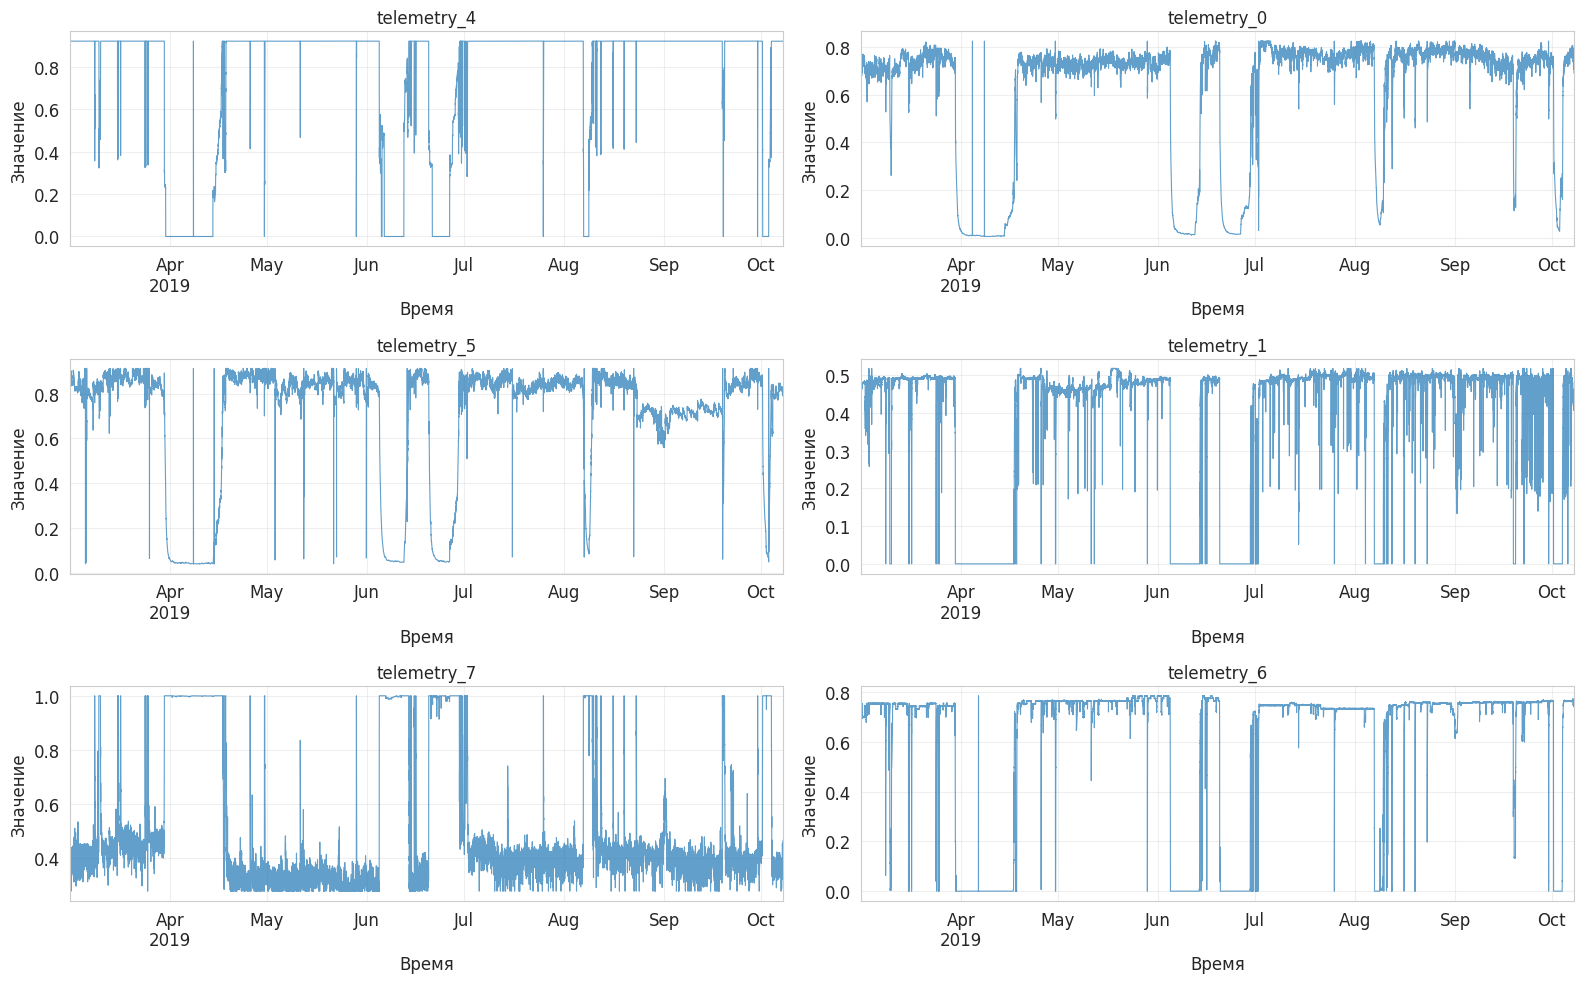

In [5]:
target_raw = target_raw.sort_values('Дата').set_index('Дата')[['target']].copy()
print(f"Телеметрия: {telemetry_raw.shape}")
print(f"Целевая переменная: {target_raw.shape}")

# Отбор каналов для визуализации (первые 6 из обработанных)
show_cols = telemetry_raw.columns[:6] if len(telemetry_raw.columns) >= 6 else telemetry_raw.columns

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(show_cols):
    telemetry_raw[col].plot(ax=axes[idx], linewidth=0.8, alpha=0.7)
    axes[idx].set_title(col, fontsize=12)
    axes[idx].set_xlabel('Время')
    axes[idx].set_ylabel('Значение')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Проведём анализов трендов:

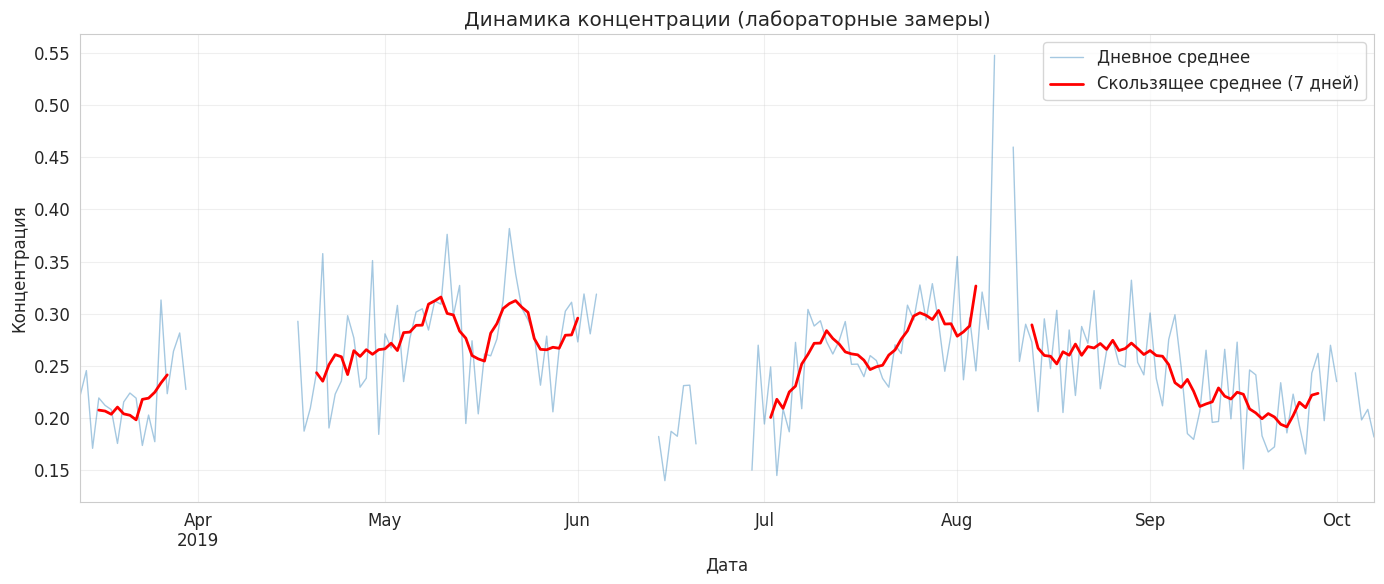


Статистика вариативности:
	Диапазон суточных средних: [0.1400, 0.5477]
	Стандартное отклонение: 0.0922


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

# Скользящее среднее для визуализации тренда
target_daily = target_raw['target'].resample('D').mean()
target_daily.plot(ax=ax, label='Дневное среднее', alpha=0.4, linewidth=1)
target_daily.rolling(window=7, center=True).mean().plot(
    ax=ax, label='Скользящее среднее (7 дней)', linewidth=2, color='red'
)
ax.set_title('Динамика концентрации (лабораторные замеры)')
ax.set_xlabel('Дата')
ax.set_ylabel('Концентрация')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nСтатистика вариативности:")
print(f"\tДиапазон суточных средних: [{target_daily.min():.4f}, {target_daily.max():.4f}]")
print(f"\tСтандартное отклонение: {target_raw['target'].std():.4f}")

На графике заметны существенные пропуски значений, которые совпадают с периодами отсутствия лабораторных измерений. Это может быть связано с технологическими остановками производства или выходными днями и подтверждает нерегулярность отбора проб.

Также в августе наблюдается аномальный рост концентрации до значения около 0.55, что выходит за пределы типичного диапазона
[0.1400; 0.5477]. Подобное отклонение может свидетельствовать о нештатном режиме работы технологического процесса и подтверждает целесообразность обработки выбросов для повышения устойчивости прогнозной модели.

Проведём исследования целевой переменной:

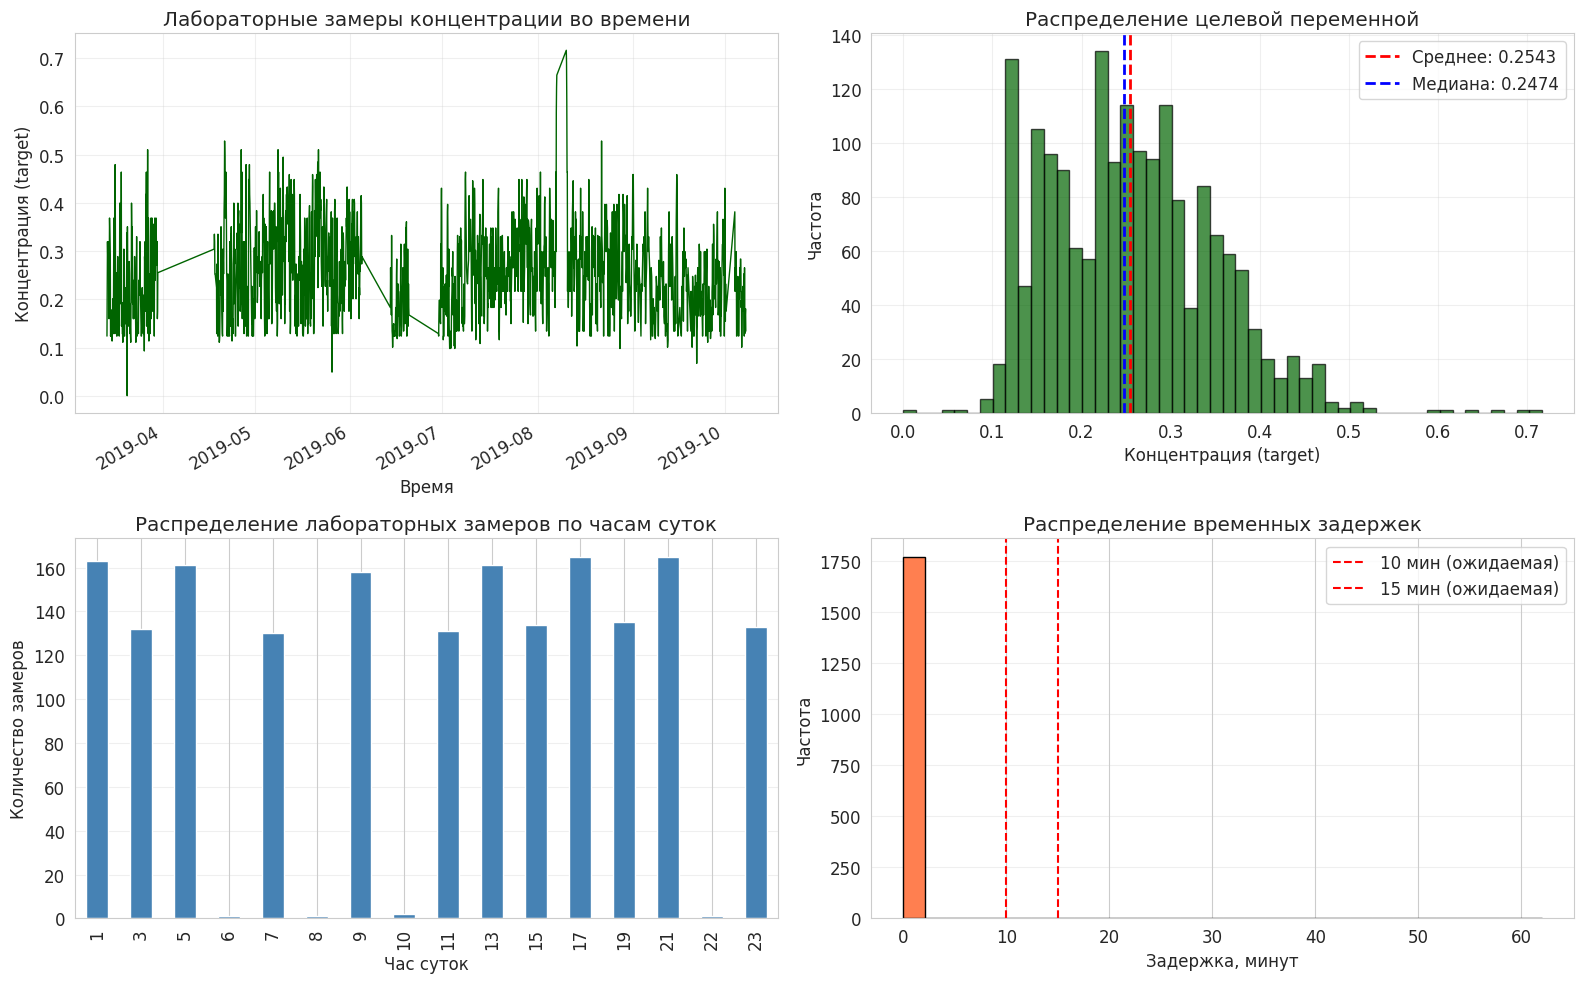


Статистика целевой переменной:
	Количество замеров: 1773
	Среднее значение: 0.2543
	Стандартное отклонение: 0.0922
	Диапазон: [0.0000, 0.7165]

Статистика временных задержек (телеметрия → лабораторный замер):
	Средняя задержка: 0.03 мин
	Медианная задержка: 0.00 мин
	Диапазон задержек: [0.00, 62.00] мин
	Доля задержек в диапазоне 10-15 мин: 0.0%


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

target_raw['target'].plot(ax=axes[0, 0], linewidth=1, color='darkgreen')
axes[0, 0].set_title('Лабораторные замеры концентрации во времени')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Концентрация (target)')
axes[0, 0].grid(True, alpha=0.3)

target_raw['target'].hist(bins=50, ax=axes[0, 1], color='darkgreen', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(target_raw['target'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {target_raw["target"].mean():.4f}')
axes[0, 1].axvline(target_raw['target'].median(), color='blue', linestyle='--', linewidth=2, label=f'Медиана: {target_raw["target"].median():.4f}')
axes[0, 1].set_title('Распределение целевой переменной')
axes[0, 1].set_xlabel('Концентрация (target)')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

hour_counts = target_raw.index.hour.value_counts().sort_index()
hour_counts.plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Распределение лабораторных замеров по часам суток')
axes[1, 0].set_xlabel('Час суток')
axes[1, 0].set_ylabel('Количество замеров')
axes[1, 0].grid(True, alpha=0.3, axis='y')

telemetry_times = pd.Series(telemetry_raw.index)
delays_minutes = []

for ts in target_raw.index:
    time_diff = (telemetry_times - ts).abs()
    nearest_idx = time_diff.idxmin()
    nearest_ts = telemetry_times.loc[nearest_idx]
    delay = abs((ts - nearest_ts).total_seconds()) / 60
    delays_minutes.append(delay)

delay_series = pd.Series(delays_minutes)
axes[1, 1].hist(delay_series, bins=30, color='coral', edgecolor='black')
axes[1, 1].axvline(x=10, color='red', linestyle='--', label='10 мин (ожидаемая)')
axes[1, 1].axvline(x=15, color='red', linestyle='--', label='15 мин (ожидаемая)')
axes[1, 1].set_title('Распределение временных задержек')
axes[1, 1].set_xlabel('Задержка, минут')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nСтатистика целевой переменной:")
print(f"\tКоличество замеров: {len(target_raw)}")
print(f"\tСреднее значение: {target_raw['target'].mean():.4f}")
print(f"\tСтандартное отклонение: {target_raw['target'].std():.4f}")
print(f"\tДиапазон: [{target_raw['target'].min():.4f}, {target_raw['target'].max():.4f}]")

print(f"\nСтатистика временных задержек (телеметрия → лабораторный замер):")
print(f"\tСредняя задержка: {delay_series.mean():.2f} мин")
print(f"\tМедианная задержка: {delay_series.median():.2f} мин")
print(f"\tДиапазон задержек: [{delay_series.min():.2f}, {delay_series.max():.2f}] мин")
print(f"\tДоля задержек в диапазоне 10-15 мин: {(delay_series.between(10, 15)).mean() * 100:.1f}%")

Большинство измерений характеризуются нулевой задержкой, что свидетельствует о синхронности временных меток. Это указывает на то, что в датасете отражено время фактического отбора проб оператором, а не момент получения результатов лабораторного анализа.

Для корректного построения прогноза необходимо учитывать телеметрические данные с лагом порядка 10–15 минут относительно времени измерения целевого показателя. Такой подход обусловлен физикой процесса, поскольку формирование концентрации продукта происходит с временной задержкой по отношению к текущим параметрам работы печи.

Выполним  синхронизацию двух источников данных (минутная телеметрия + нерегулярные лабораторные замеры) с учётом временной задержки отбора проб:

In [8]:
# Подготовка телеметрии: сброс индекса для merge_asof
telemetry_clean = telemetry_raw.reset_index().copy().ffill().bfill()
telemetry_cols = telemetry_clean.columns.tolist()

# Тестирование различных задержек
lag_quality = []
for delay in range(10, 16):
    # Создаем копию target и сдвигаем время отбора проб
    aligned = target_raw.reset_index().copy()
    aligned['sample_time'] = aligned['Дата'] - pd.Timedelta(minutes=delay)

    # Синхронизация через merge_asof
    merged = pd.merge_asof(
        aligned.sort_values('sample_time'),
        telemetry_clean.sort_values('datetime'),
        left_on='sample_time',
        right_on='datetime',
        direction='backward',
        suffixes=('', '_drop')
    )

    # Расчёт корреляций
    corr_values = merged[telemetry_cols + ['target']].corr()['target'].drop('target').abs()
    lag_quality.append({
        'delay_min': delay,
        'mean_abs_corr': corr_values.mean(),
        'max_abs_corr': corr_values.max()
    })

# Анализ качества лагов
lag_quality_df = pd.DataFrame(lag_quality).sort_values(
    ['mean_abs_corr', 'max_abs_corr'],
    ascending=False
)

print("\nКачество синхронизации по различным задержкам:")
print(lag_quality_df.to_string(index=False))

# Выбор оптимальной задержки
BEST_DELAY = int(lag_quality_df.iloc[0]['delay_min'])
print(f"\nВыбрана оптимальная задержка: {BEST_DELAY} минут")
print(f"Средняя абсолютная корреляция: {lag_quality_df.iloc[0]['mean_abs_corr']:.4f}")
print(f"Максимальная абсолютная корреляция: {lag_quality_df.iloc[0]['max_abs_corr']:.4f}")

# Финальная синхронизация с выбранной задержкой
target_sync = target_raw.reset_index().copy()
target_sync['sample_time'] = target_sync['Дата'] - pd.Timedelta(minutes=BEST_DELAY)

df_merged = pd.merge_asof(
    target_sync.sort_values('sample_time'),
    telemetry_clean.sort_values('datetime'),
    left_on='sample_time',
    right_on='datetime',
    direction='backward'
)

# Удаление вспомогательных колонок
df_merged = df_merged.drop(columns=['sample_time', 'datetime'])
df_merged = df_merged.set_index('Дата')

print(f"\nРазмер синхронизированного датасета: {df_merged.shape}")
print(f"Количество признаков: {len(telemetry_cols)}")
print(f"Количество лабораторных замеров: {len(target_raw)}")


Качество синхронизации по различным задержкам:
 delay_min  mean_abs_corr  max_abs_corr
        11       0.080501      0.177857
        12       0.080078      0.176303
        13       0.079802      0.175382
        10       0.079677      0.179413
        14       0.079125      0.174379
        15       0.079038      0.173326

Выбрана оптимальная задержка: 11 минут
Средняя абсолютная корреляция: 0.0805
Максимальная абсолютная корреляция: 0.1779

Размер синхронизированного датасета: (1773, 13)
Количество признаков: 13
Количество лабораторных замеров: 1773


Эмпирический анализ временных сдвигов показал, что наилучшим значением лага является 11 минут: именно при таком смещении достигается максимальное среднее значение абсолютной корреляции между телеметрическими признаками и целевой переменной (0.0805).

При этом невысокие значения коэффициентов корреляции указывают на слабую линейную связь между параметрами телеметрии и концентрацией продукта. Это свидетельствует о вероятном наличии более сложных, нелинейных зависимостей и обосновывает необходимость использования более продвинутых подходов к моделированию, а также расширенного набора признаков, включая лаговые переменные и скользящие статистики, для повышения точности прогнозирования.

Выполним корреляционный анализ между признаками телеметрии и целевой переменной (с учётом лагов):

Топ-10 каналов по абсолютной корреляции с target (лаг 11 мин):
  telemetry_0: -0.1779
  telemetry_3: -0.1243
  telemetry_9: -0.1235
  telemetry_6: -0.0932
  telemetry_11: -0.0922
  telemetry_8: +0.0877
  telemetry_4: -0.0775
  telemetry_5: -0.0731
  telemetry_10: -0.0713
  telemetry_7: -0.0450


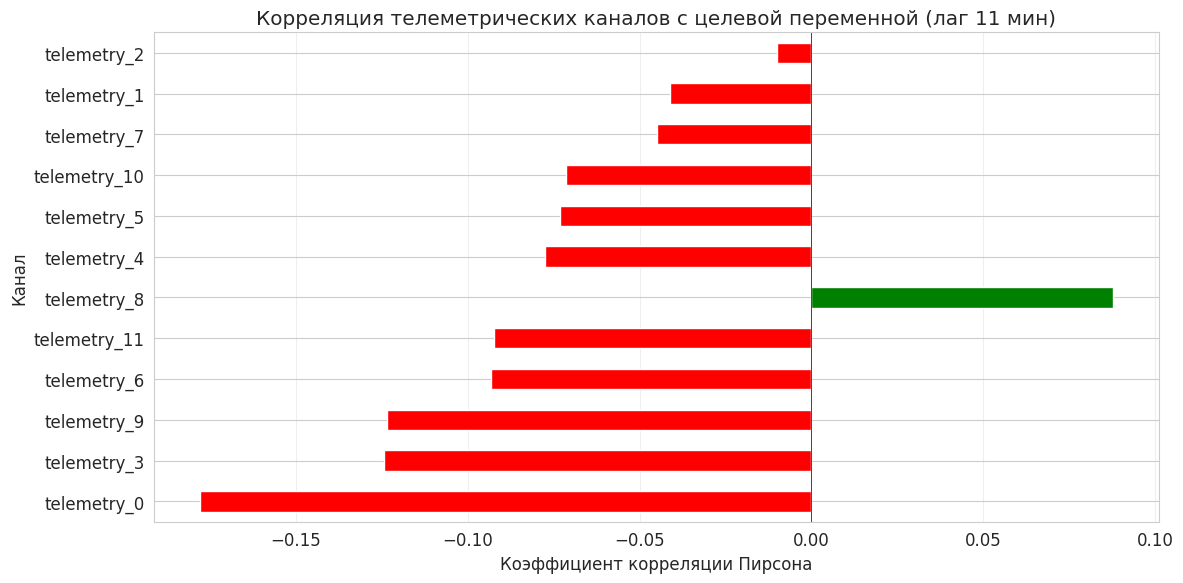


Всего проанализировано каналов: 12
Средняя абсолютная корреляция: 0.0847
Максимальная абсолютная корреляция: 0.1779


In [9]:
correlations = {}

# Получаем список признаков из df_merged (исключая target)
feature_cols = [col for col in df_merged.columns if col != 'target']
for col in feature_cols:
    telemetry_values = df_merged[col]
    target_values = df_merged['target']

    # Расчет корреляции Пирсона
    mask = telemetry_values.notna() & target_values.notna()
    if mask.sum() > 30:
        corr = np.corrcoef(telemetry_values[mask], target_values[mask])[0, 1]
        correlations[col] = corr
    else:
        correlations[col] = 0.0

# Сортировка по абсолютному значению корреляции
corr_series = pd.Series(correlations).sort_values(ascending=False, key=abs)

# Вывод топ-10 корреляций
print(f"Топ-10 каналов по абсолютной корреляции с target (лаг {BEST_DELAY} мин):")
for col, corr in corr_series.head(10).items():
    print(f"  {col}: {corr:+.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in corr_series.head(15)]
corr_series.head(15).plot(kind='barh', ax=ax, color=colors)
ax.set_title(f'Корреляция телеметрических каналов с целевой переменной (лаг {BEST_DELAY} мин)')
ax.set_xlabel('Коэффициент корреляции Пирсона')
ax.set_ylabel('Канал')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\nВсего проанализировано каналов: {len(corr_series)}")
print(f"Средняя абсолютная корреляция: {corr_series.abs().mean():.4f}")
print(f"Максимальная абсолютная корреляция: {corr_series.abs().max():.4f}")

Наиболее выраженную обратную связь с целевой переменной демонстрирует признак **telemetry_0**, имеющий коэффициент корреляции −0.1779, что указывает на заметную отрицательную зависимость между этим параметром и концентрацией продукта.

В то же время единственным признаком, показывающим положительную линейную связь с целевой переменной, является **telemetry_8** с коэффициентом корреляции +0.0877. Однако степень его влияния существенно ниже по сравнению с признаками, имеющими отрицательную корреляцию, что говорит о его менее значимом вкладе в изменение целевого показателя.

### Выводы:

Проведённый разведочный анализ показал, что телеметрические данные обладают нестационарностью и не демонстрируют выраженной сезонности или цикличности. Также были выявлены пропуски в отдельных каналах и выбросы, которые были сглажены с помощью винзоризации.

Синхронизация телеметрии и лабораторных измерений с использованием эмпирически подобранного лага в 11 минут, а также последующий корреляционный анализ выявили слабую линейную зависимость между признаками и целевой переменной (максимальный коэффициент корреляции около 0.18). Это указывает на сложный и преимущественно нелинейный характер технологического процесса.

Полученные результаты подтверждают целесообразность применения методов машинного обучения с предварительным инжинирингом признаков, включая лаговые переменные и скользящие статистики, что необходимо для построения более точной и устойчивой прогнозной модели.

# 2 | Инжиниринг признаков для временных рядов

Напишем функцию для построения датасета с учётом задержки:

In [10]:
# Лаги для построения признаков (в минутах)
LAG_LIST_MIN = [1, 5, 10, 15, 30, 60]
# Окна для скользящих статистик (в минутах)
WINDOWS_MIN = [10, 20, 30, 60]


def build_prepared_dataset(
    telemetry_df: pd.DataFrame,
    target_df: pd.DataFrame,
    delay_min: int,
    lag_list_min: list,
    rolling_windows_min: list,
    telemetry_cols: list,
    rolling_stats: tuple = ('mean', 'std'),
    include_derivatives: bool = False,
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Строит матрицу признаков X для предсказания y(t_lab) из телеметрии
    в момент отбора пробы: anchor = t_lab - delay_min.
    """
    anchor_times = target_df.index - pd.Timedelta(minutes=delay_min)

    X = {
        'hour_of_day': anchor_times.hour,
        'day_of_week': anchor_times.dayofweek,
        'month': anchor_times.month,
        'minute_of_hour': anchor_times.minute,
    }

    for col in telemetry_cols:
        s = telemetry_df[col]

        for lag in lag_list_min:
            t = anchor_times - pd.Timedelta(minutes=lag)
            X[f'{col}_lag_{lag}'] = s.reindex(t).to_numpy()

        if include_derivatives:
            diff1 = s.diff(1)
            X[f'{col}_diff_1'] = diff1.reindex(anchor_times).to_numpy()
            pct1 = s.pct_change(1)
            X[f'{col}_pct_change_1'] = pct1.reindex(anchor_times).to_numpy()

        for w in rolling_windows_min:
            if 'mean' in rolling_stats:
                roll_mean = s.rolling(window=w, min_periods=max(2, w // 2)).mean()
                X[f'{col}_roll_mean_{w}'] = roll_mean.reindex(anchor_times).to_numpy()
            if 'std' in rolling_stats:
                roll_std = s.rolling(window=w, min_periods=max(2, w // 2)).std()
                X[f'{col}_roll_std_{w}'] = roll_std.reindex(anchor_times).to_numpy()
            if 'min' in rolling_stats:
                roll_min = s.rolling(window=w, min_periods=max(2, w // 2)).min()
                X[f'{col}_roll_min_{w}'] = roll_min.reindex(anchor_times).to_numpy()
            if 'max' in rolling_stats:
                roll_max = s.rolling(window=w, min_periods=max(2, w // 2)).max()
                X[f'{col}_roll_max_{w}'] = roll_max.reindex(anchor_times).to_numpy()

    X_df = pd.DataFrame(X, index=target_df.index)
    y = target_df['target'].copy()

    valid_mask = X_df.notna().all(axis=1)
    X_df = X_df.loc[valid_mask]
    y = y.loc[valid_mask]

    return X_df, y

print(f"\nПараметры генерации признаков:")
print(f"\tОптимальная задержка: {BEST_DELAY} минут")
print(f"\tЛаги: {LAG_LIST_MIN}")
print(f"\tОкна скользящих статистик: {WINDOWS_MIN}")
print(f"\tСтатистики: mean, std, min, max")
print(f"\tПроизводные признаки: diff, pct_change")

X_all, y_all = build_prepared_dataset(
    telemetry_df=telemetry_raw,
    target_df=target_raw,
    delay_min=BEST_DELAY,
    lag_list_min=LAG_LIST_MIN,
    rolling_windows_min=WINDOWS_MIN,
    telemetry_cols=list(telemetry_raw.columns),
    rolling_stats=('mean', 'std', 'min', 'max'),
    include_derivatives=True,
)

print(f"\nРазмерность данных:")
print(f"  Количество наблюдений: {X_all.shape[0]:,}")
print(f"  Количество признаков: {X_all.shape[1]:,}")


Параметры генерации признаков:
	Оптимальная задержка: 11 минут
	Лаги: [1, 5, 10, 15, 30, 60]
	Окна скользящих статистик: [10, 20, 30, 60]
	Статистики: mean, std, min, max
	Производные признаки: diff, pct_change

Размерность данных:
  Количество наблюдений: 1,762
  Количество признаков: 292


Разделим данные на обучающую и тестовые выборки:

In [12]:
# Доля обучающей выборки при time-based split
TRAIN_FRACTION = 0.8

split_idx = int(len(y_all) * TRAIN_FRACTION)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Соотношение train/test: {len(y_train)}/{len(y_test)}")


Обучающая выборка: (1409, 292)
Тестовая выборка: (353, 292)
Соотношение train/test: 1409/353


Выполним отбор признаков на основе взаимной информации (Mutual Information):

In [13]:
from sklearn.feature_selection import mutual_info_regression


mi_scores = mutual_info_regression(X_train.fillna(0), y_train)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Отбор топ-N признаков для разных моделей
n_features_ols = min(50, X_train.shape[1])
n_features_full = min(150, X_train.shape[1])

selected_features_ols = mi_series.head(n_features_ols).index.tolist()
selected_features_full = mi_series.head(n_features_full).index.tolist()

X_train_ols = X_train[selected_features_ols].copy()
X_test_ols = X_test[selected_features_ols].copy()

X_train_selected = X_train[selected_features_full].copy()
X_test_selected = X_test[selected_features_full].copy()

print(f"\nРезультаты отбора признаков:")
print(f"\tДля OLS модели: {len(selected_features_ols)} признаков")
print(f"\tДля ML моделей: {len(selected_features_full)} признаков")

print(f"\nТоп-10 признаков по mutual information:")
for i, (feat, score) in enumerate(mi_series.head(10).items(), 1):
    print(f"\t{i:2d}. {feat:50s} : {score:.6f}")


Результаты отбора признаков:
	Для OLS модели: 50 признаков
	Для ML моделей: 150 признаков

Топ-10 признаков по mutual information:
	 1. month                                              : 0.473412
	 2. telemetry_6_roll_min_20                            : 0.328866
	 3. telemetry_6_roll_mean_20                           : 0.325812
	 4. telemetry_6_roll_mean_30                           : 0.314320
	 5. telemetry_6_lag_15                                 : 0.310394
	 6. telemetry_6_roll_max_20                            : 0.309585
	 7. telemetry_6_roll_mean_10                           : 0.308054
	 8. telemetry_6_roll_min_60                            : 0.305966
	 9. telemetry_6_roll_min_30                            : 0.303217
	10. telemetry_6_roll_mean_60                           : 0.296937


Выполним снижение размерности методом PCA:

In [14]:
from sklearn.decomposition import PCA


# PCA для отобранных признаков
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

print(f"\nРезультаты PCA:")
print(f"\tИсходное количество признаков: {X_train_selected.shape[1]}")
print(f"\tПосле PCA: {X_train_pca.shape[1]}")
print(f"\tСокращение: {(1 - X_train_pca.shape[1] / X_train_selected.shape[1]) * 100:.1f}%")
print(f"\tОбъяснённая дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

print(f"\nТоп-5 главных компонент:")
for i, var in enumerate(pca.explained_variance_ratio_[:5], 1):
    print(f"\tPC{i:2d}: {var:.6f} ({var*100:.2f}%)")


Результаты PCA:
	Исходное количество признаков: 150
	После PCA: 3
	Сокращение: 98.0%
	Объяснённая дисперсия: 0.9627

Топ-5 главных компонент:
	PC 1: 0.817968 (81.80%)
	PC 2: 0.088981 (8.90%)
	PC 3: 0.055788 (5.58%)


Выполним анализ признаков:


Распределение признаков по типам:
  lag            :   72 ( 24.7%)
  roll_mean      :   48 ( 16.4%)
  roll_std       :   48 ( 16.4%)
  roll_min       :   48 ( 16.4%)
  roll_max       :   48 ( 16.4%)
  diff           :   12 (  4.1%)
  pct_change     :   12 (  4.1%)
  calendar       :    4 (  1.4%)


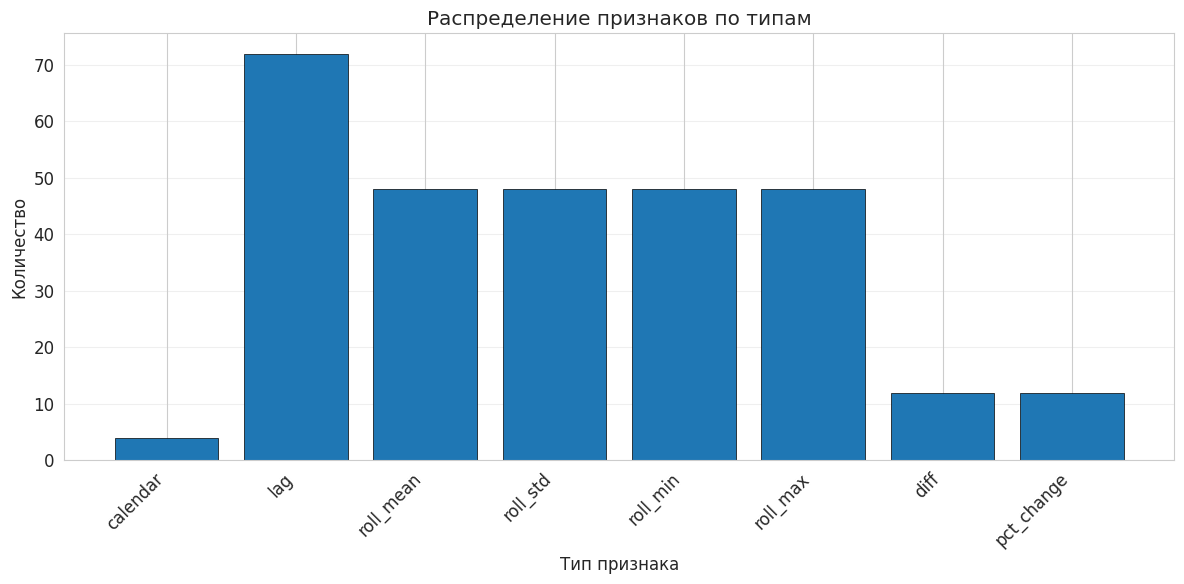


Всего признаков: 292


In [15]:
feature_types = {
    'calendar': [],
    'lag': [],
    'roll_mean': [],
    'roll_std': [],
    'roll_min': [],
    'roll_max': [],
    'diff': [],
    'pct_change': []
}

feature_patterns = {
    'lag': 'lag_',
    'roll_mean': 'roll_mean_',
    'roll_std': 'roll_std_',
    'roll_min': 'roll_min_',
    'roll_max': 'roll_max_',
    'diff': '_diff_',
    'pct_change': '_pct_change_'
}

for feat in X_all.columns:
    matched = False
    for key, pattern in feature_patterns.items():
        if pattern in feat:
            feature_types[key].append(feat)
            matched = True
            break
    if not matched:
        feature_types['calendar'].append(feat)

type_counts = {k: len(v) for k, v in feature_types.items() if len(v) > 0}
print(f"\nРаспределение признаков по типам:")
for ftype, count in sorted(type_counts.items(), key=lambda x: x[1], reverse=True):
    pct = (count / X_all.shape[1]) * 100
    print(f"  {ftype:15s}: {count:4d} ({pct:5.1f}%)")

fig, ax = plt.subplots(figsize=(12, 6))
type_names = list(type_counts.keys())
type_values = list(type_counts.values())
ax.bar(type_names, type_values, edgecolor='black', linewidth=0.5)
ax.set_title('Распределение признаков по типам')
ax.set_xlabel('Тип признака')
ax.set_ylabel('Количество')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nВсего признаков: {X_all.shape[1]}")

Сгенерированный набор из 292 признаков включает лаговые значения (24,7%), скользящие статистики (65,6%) и производные показатели (8,2%). Доминирование скользящих статистик с разными окнами даёт модели возможность учитывать инерционные характеристики процесса обжига на различных временных масштабах, что является ключевым для точного прогнозирования концентрации продукта.

### Обоснование выбора признаков:

Лаговые признаки и скользящие статистики позволяют учитывать инерционность процесса обжига, предоставляя модели информацию не только о текущих значениях параметров, но и об их исторической динамике на различных временных интервалах. Производные признаки, такие как **diff** и **pct_change**, отражают скорость изменения технологических показателей и могут использоваться для более раннего выявления отклонений от нормального режима работы.

Использование методов отбора признаков на основе Mutual Information, а также снижение размерности с помощью PCA позволяют снизить риск переобучения при работе с большим количеством признаков (292). При этом для интерпретируемых моделей, таких как OLS, используется 50 наиболее информативных признаков, тогда как для ансамблевых методов — около 150. Такой подход обеспечивает разумный компромисс между качеством прогноза и возможностью физической интерпретации полученных результатов.

# 3 | Построение прогнозных моделей

### Подходящие модели:

*   **OLS** - Даёт интерпретируемую статистическую базовую модель и позволяет считать AIC/BIC. Служит бенчмарком для оценки нелинейных моделей.
*   **Random Forest Regressor** - Подходит для улавливания нелинейных зависимостей и взаимодействий признаков.
*   **Gradient Boosting Regressor** - Подходит для сложных зависимостей, чувствителен к важным признакам и позволяет получать точные прогнозы на данных с высокой вариативностью.

### Неподходящие модели:
*   **ARIMA** / **SARIMA** — Несмотря на широкое применение в задачах прогнозирования временных рядов, данные модели менее эффективны в условиях большого количества экзогенных признаков и сложных нелинейных взаимодействий между технологическими параметрами печи. Кроме того, данные подходы ориентированы преимущественно на моделирование структуры самого временного ряда, тогда как в данной задаче основная информация содержится именно в многомерной телеметрии процесса.
*   **KNN Regressor** — Демонстрирует низкую вычислительную эффективность при работе с большими объёмами данных и высокой размерностью признакового пространства. Также модель чувствительна к шуму и не учитывает временную структуру данных, что может приводить к нестабильным прогнозам.
*   Модели без учёта временной динамики — например, простые регрессионные модели без использования лаговых признаков и временных агрегатов не способны учитывать инерционность технологического процесса и задержанное влияние параметров печи на целевой показатель, что критично для данной задачи.

Таким образом, выбранные модели обеспечивают разумный компромисс между интерпретируемостью, вычислительной эффективностью и способностью выявлять сложные нелинейные зависимости в многомерных временных рядах.

In [23]:
X_test = X_test.sort_index()
y_test = y_test.sort_index()

results = []
preds_by_model = {}
models = {}
RANDOM_SEED = 40

Обучим **OLS (Ordinary Least Squares)**:

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.feature_selection import mutual_info_regression


def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


def directional_accuracy(y_true, y_pred):
    if len(y_true) < 2:
        return np.nan
    dy_true = np.diff(y_true)
    dy_pred = np.diff(y_pred)
    mask = np.abs(dy_true) > 1e-6
    if not mask.any():
        return np.nan
    return np.mean(np.sign(dy_true[mask]) == np.sign(dy_pred[mask]))


mi = mutual_info_regression(X_train.fillna(0), y_train, random_state=RANDOM_SEED)

selected = (
    pd.Series(mi, index=X_train.columns)
    .nlargest(min(50, X_train.shape[1]))
    .index
)

X_train_ols = sm.add_constant(X_train[selected])
X_test_ols = sm.add_constant(X_test[selected])

print(f"Обучение OLS на {X_train_ols.shape[1]} признаках...")

start = time.time()
ols_res = sm.OLS(y_train, X_train_ols).fit()
fit_time = time.time() - start

start = time.time()
pred_ols = ols_res.predict(X_test_ols)
pred_time = time.time() - start

preds_by_model['OLS'] = pred_ols
models['OLS'] = ols_res

metrics = {
    'MAE': mean_absolute_error(y_test, pred_ols),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_ols)),
    'MAPE_%': mean_absolute_percentage_error(y_test, pred_ols) * 100,
    'WAPE': wape(y_test, pred_ols),
    'R2': r2_score(y_test, pred_ols),
    'directional_acc': directional_accuracy(y_test, pred_ols),
}

results.append({
    'model': 'OLS',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    **metrics,
    'AIC': ols_res.aic,
    'BIC': ols_res.bic,
})

print("\nРезультаты OLS:")
print(f"\tMAE:  {metrics['MAE']:.6f}")
print(f"\tRMSE: {metrics['RMSE']:.6f}")
print(f"\tR2:   {metrics['R2']:.4f}")
print(f"\tAIC:  {ols_res.aic:.2f}")
print(f"\tBIC:  {ols_res.bic:.2f}")

Обучение OLS на 51 признаках...

Результаты OLS:
	MAE:  0.117618
	RMSE: 0.138261
	R2:   -2.2809
	AIC:  -2938.19
	BIC:  -2670.41


Обучим **Random Forest Regressor**:

In [25]:
# количество итераций
ITERATIONS = 300

from sklearn.ensemble import RandomForestRegressor

print(f"Обучение RandomForest ({ITERATIONS} деревьев)...")

start = time.time()

rf_model = RandomForestRegressor(
    n_estimators=ITERATIONS,
    random_state=RANDOM_SEED,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

fit_time = time.time() - start
print(f"Обучение завершено за {fit_time:.2f} сек")

start = time.time()
pred_rf = rf_model.predict(X_test)
pred_time = time.time() - start

preds_by_model['RandomForest'] = pred_rf
models['RandomForest'] = rf_model

metrics = {
    'MAE': mean_absolute_error(y_test, pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
    'MAPE_%': mean_absolute_percentage_error(y_test, pred_rf) * 100,
    'WAPE': wape(y_test, pred_rf),
    'R2': r2_score(y_test, pred_rf),
    'directional_acc': directional_accuracy(y_test, pred_rf),
}

results.append({
    'model': 'RandomForest',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    **metrics,
    'AIC': np.nan,
    'BIC': np.nan,
})

print("\nРезультаты RandomForest:")
print(f"\tMAE:  {metrics['MAE']:.6f}")
print(f"\tRMSE: {metrics['RMSE']:.6f}")
print(f"\tR2:   {metrics['R2']:.4f}")

Обучение RandomForest (300 деревьев)...
Обучение завершено за 79.91 сек

Результаты RandomForest:
	MAE:  0.072785
	RMSE: 0.088343
	R2:   -0.3395


Обучим **Gradient Boosting Regressor**:

In [26]:
# количество итераций
ITERATIONS = 300

print(f"Обучение GradientBoosting ({ITERATIONS} итераций)...")

start = time.time()

gb_model = GradientBoostingRegressor(
    n_estimators=ITERATIONS,
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_split=5,
    min_samples_leaf=2,
)

gb_model.fit(X_train, y_train)

fit_time = time.time() - start
print(f"Обучение завершено за {fit_time:.2f} сек")

start = time.time()
pred_gb = gb_model.predict(X_test)
pred_time = time.time() - start

preds_by_model['GradientBoosting'] = pred_gb
models['GradientBoosting'] = gb_model

metrics = {
    'MAE': mean_absolute_error(y_test, pred_gb),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_gb)),
    'MAPE_%': mean_absolute_percentage_error(y_test, pred_gb) * 100,
    'WAPE': wape(y_test, pred_gb),
    'R2': r2_score(y_test, pred_gb),
    'directional_acc': directional_accuracy(y_test, pred_gb),
}

results.append({
    'model': 'GradientBoosting',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    **metrics,
    'AIC': np.nan,
    'BIC': np.nan,
})

print("\nРезультаты GradientBoosting:")
print(f"\tMAE:  {metrics['MAE']:.6f}")
print(f"\tRMSE: {metrics['RMSE']:.6f}")
print(f"\tR2:   {metrics['R2']:.4f}")

Обучение GradientBoosting (300 итераций)...
Обучение завершено за 63.66 сек

Результаты GradientBoosting:
	MAE:  0.070854
	RMSE: 0.087730
	R2:   -0.3210


# 4 | Оценка качества моделей

Сравним полученные показатели моделей:

In [27]:
res_df = pd.DataFrame(results).sort_values('MAE')
print(f"\n{res_df.to_string(index=False)}")

best_model_name = res_df.iloc[0]['model']
print(f"\nЛучшая модель: {best_model_name} (MAE = {res_df.iloc[0]['MAE']:.6f})")


           model  fit_time_s  pred_time_s      MAE     RMSE    MAPE_%     WAPE        R2  directional_acc          AIC          BIC
GradientBoosting   63.660577     0.012530 0.070854 0.087730 39.153020 0.313604 -0.320963         0.500000          NaN          NaN
    RandomForest   79.905988     0.105012 0.072785 0.088343 41.505302 0.322151 -0.339489         0.568862          NaN          NaN
             OLS    0.349883     0.000814 0.117618 0.138261 67.104386 0.520585 -2.280864         0.455090 -2938.192045 -2670.409634

Лучшая модель: GradientBoosting (MAE = 0.070854)


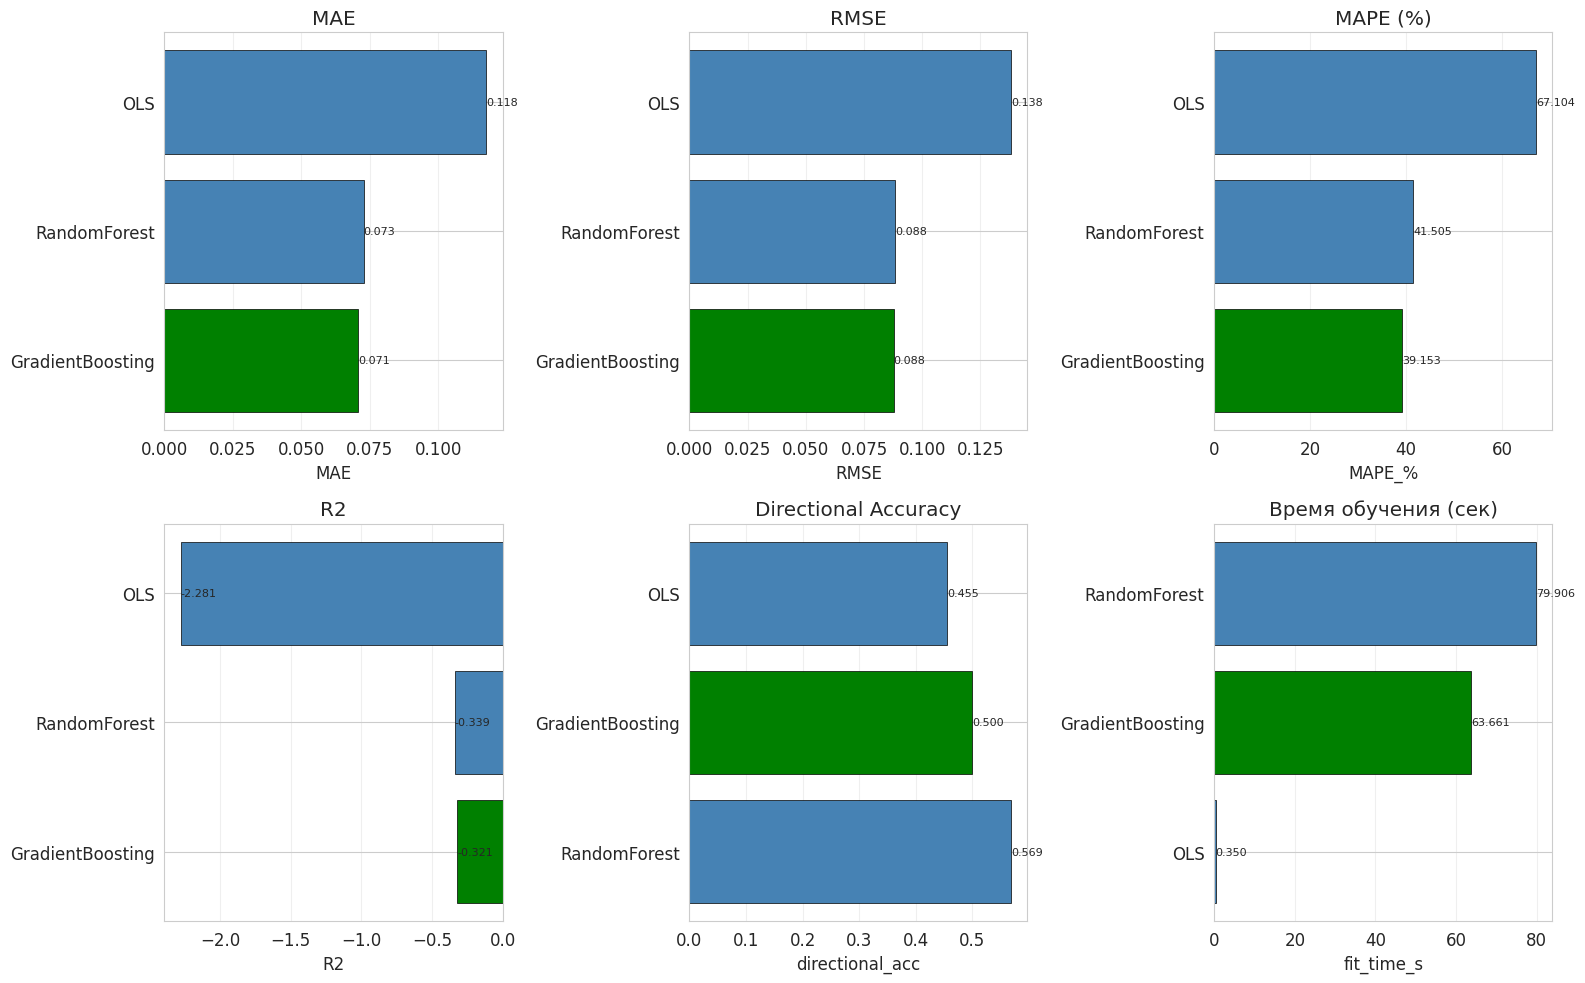

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plots = [
    ('MAE', 'MAE', True),
    ('RMSE', 'RMSE', True),
    ('MAPE_%', 'MAPE (%)', True),
    ('R2', 'R2', False),
    ('directional_acc', 'Directional Accuracy', False),
    ('fit_time_s', 'Время обучения (сек)', True),
]

for ax, (metric, title, asc) in zip(axes.flat, plots):

    data = res_df.sort_values(metric, ascending=asc)

    colors = [
        'green' if m == best_model_name else 'steelblue'
        for m in data['model']
    ]

    ax.barh(data['model'], data[metric],
            color=colors,
            edgecolor='black',
            linewidth=0.5)

    ax.set(title=title, xlabel=metric)
    ax.grid(axis='x', alpha=0.3)

    for bar in ax.patches:
        val = bar.get_width()
        if pd.notna(val):
            ax.text(
                val,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}',
                va='center',
                fontsize=8
            )

plt.tight_layout()
plt.show()

Визуализируем прогнозы моделей против реальных лабораторных замеров в динамике:

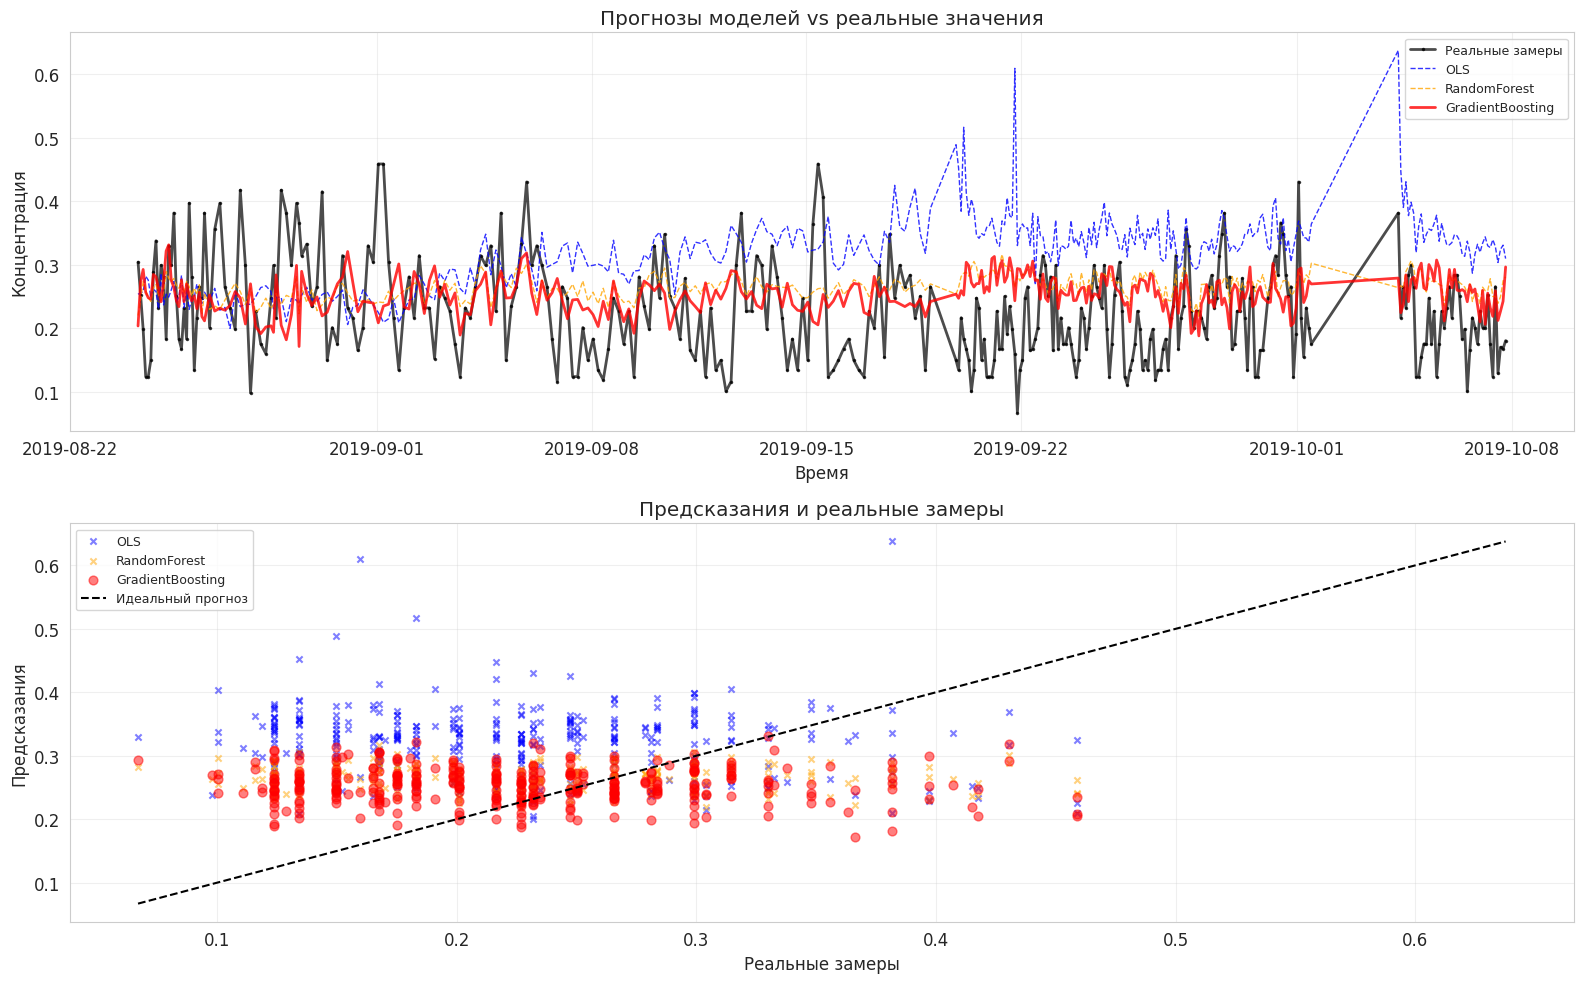

Лучшая модель по MAE: GradientBoosting


In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

colors = {
    'OLS': 'blue',
    'ExtraTrees': 'green',
    'RandomForest': 'orange',
    'GradientBoosting': 'red'
}

ax1.plot(
    y_test.index, y_test,
    label='Реальные замеры',
    color='black',
    lw=2,
    marker='.',
    ms=3,
    alpha=0.7
)

for name, preds in preds_by_model.items():
    best = name == best_model_name
    ax1.plot(
        y_test.index,
        preds,
        label=name,
        color=colors.get(name, 'gray'),
        lw=2 if best else 1,
        ls='-' if best else '--',
        alpha=0.8
    )

ax1.set(
    title='Прогнозы моделей vs реальные значения',
    xlabel='Время',
    ylabel='Концентрация'
)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

all_preds = np.concatenate(list(preds_by_model.values()))
min_val = min(y_test.min(), all_preds.min())
max_val = max(y_test.max(), all_preds.max())
for name, preds in preds_by_model.items():

    best = name == best_model_name

    ax2.scatter(
        y_test,
        preds,
        label=name,
        color=colors.get(name,'gray'),
        marker='o' if best else 'x',
        s=40 if best else 20,
        alpha=0.5
    )

ax2.plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    lw=1.5,
    label='Идеальный прогноз'
)

ax2.set(
    title='Предсказания и реальные замеры',
    xlabel='Реальные замеры',
    ylabel='Предсказания'
)

ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Лучшая модель по MAE: {best_model_name}")

### Выводы:

Ансамблевые модели (**RandomForest**, **GradientBoosting**) показали лучшую точность прогнозов по сравнению с линейной моделью **OLS**: лучший *MAE = 0.071* у **GradientBoosting** против *0.118* у **OLS**.

Отрицательные значения R² на тестовой выборке указывают, что все модели прогнозируют хуже, чем константный бэйзлайн (среднее значение по обучению), что может свидетельствовать о переобучении или недостаточной информативности признаков.

Directional Accuracy около 50% у всех моделей показывает, что направление изменения концентрации предсказывается на уровне случайного угадывания — это критично для практического применения.

Наиболее вероятные причины такой низкой предсказательной способности: высокая зашумленность лабораторных измерений, неучтённые внешние факторы или неоптимальный выбор лагов и признаков.

Проведём анализ остатков:

In [30]:
best_model_name = res_df.iloc[0]['model']
best_pred = preds_by_model[best_model_name]
residuals = y_test.values - best_pred

print(f"Анализ модели: {best_model_name}")
print(f"Статистика остатков:")
print(f"\tСреднее: {residuals.mean():.6f}")
print(f"\tМедиана: {np.median(residuals):.6f}")
print(f"\tStd: {residuals.std():.6f}")
print(f"\tMin: {residuals.min():.6f}")
print(f"\tMax: {residuals.max():.6f}")

Анализ модели: GradientBoosting
Статистика остатков:
	Среднее: -0.027521
	Медиана: -0.033880
	Std: 0.083302
	Min: -0.226971
	Max: 0.253500


Проверим нормальность остатков:

In [33]:
# Тест Шапиро-Уилка (для выборок до 5000 наблюдений)
if len(residuals) <= 5000:
    shapiro_stat, shapiro_p = shapiro(residuals)
    print(f"Тест Шапиро-Уилка:")
    print(f"\tСтатистика: {shapiro_stat:.6f}")
    print(f"\tp-value: {shapiro_p:.6f}")
    print(f"\tВывод: {'нормальность не отвергается' if shapiro_p > 0.05 else 'отклонение от нормальности'} (alpha=0.05)")
else:
    print(f"\nВыборка превышает лимит для теста Шапиро-Уилка (>5000)")

# Тест Д'Агостино-Пирсона (на асимметрию и эксцесс)
dagostino_stat, dagostino_p = stats.normaltest(residuals)
print(f"\nТест Д'Агостино-Пирсона:")
print(f"\tСтатистика: {dagostino_stat:.6f}")
print(f"\tp-value: {dagostino_p:.6f}")
print(f"\tВывод: {'нормальность не отвергается' if dagostino_p > 0.05 else 'отклонение от нормальности'} (alpha=0.05)")

Тест Шапиро-Уилка:
	Статистика: 0.976636
	p-value: 0.000017
	Вывод: отклонение от нормальности (alpha=0.05)

Тест Д'Агостино-Пирсона:
	Статистика: 20.628990
	p-value: 0.000033
	Вывод: отклонение от нормальности (alpha=0.05)


Проверим автокорреляцию остатков:

In [34]:
# Тест Льюнга-Бокса для лагов 10, 20, 30
lj = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print(f"Тест Льюнга-Бокса (Ljung-Box):")
print(lj)

if (lj['lb_pvalue'] > 0.05).all():
    print(f"\nВывод: автокорреляция остатков не обнаружена (p > 0.05 для всех лагов)")
else:
    print(f"\nВывод: обнаружена статистически значимая автокорреляция остатков (p < 0.05)")
    print(f"\tВозможная причина: неучтённые временные зависимости в модели")
print("=" * 70)

Тест Льюнга-Бокса (Ljung-Box):
       lb_stat     lb_pvalue
10  138.770443  7.527169e-25
20  194.676446  1.267595e-30
30  214.673191  8.597753e-30

Вывод: обнаружена статистически значимая автокорреляция остатков (p < 0.05)
	Возможная причина: неучтённые временные зависимости в модели


Проверим гетероскедастичность остатков:

In [37]:
# Тест Бройша-Пагана: проверка зависимости дисперсии остатков от прогноза
exog_bp = sm.add_constant(best_pred, has_constant='add')
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, exog_bp)

print(f"Тест Бройша-Пагана (Breusch-Pagan):")
print(f"\tLM статистика: {bp_lm:.6f}")
print(f"\tLM p-value: {bp_p:.6f}")
print(f"\tF статистика: {bp_f:.6f}")
print(f"\tF p-value: {bp_fp:.6f}")

if bp_p > 0.05:
    print(f"\nВывод: гомоскедастичность не отвергается (p > 0.05)")
    print(f"\tДисперсия остатков постоянна, предположение выполняется")
else:
    print(f"\nВывод: обнаружена гетероскедастичность (p < 0.05)")
    print(f"\tДисперсия ошибок зависит от уровня прогноза")

Тест Бройша-Пагана (Breusch-Pagan):
	LM статистика: 2.492988
	LM p-value: 0.114354
	F статистика: 2.496494
	F p-value: 0.115001

Вывод: гомоскедастичность не отвергается (p > 0.05)
	Дисперсия остатков постоянна, предположение выполняется


Выполним визуализацию:

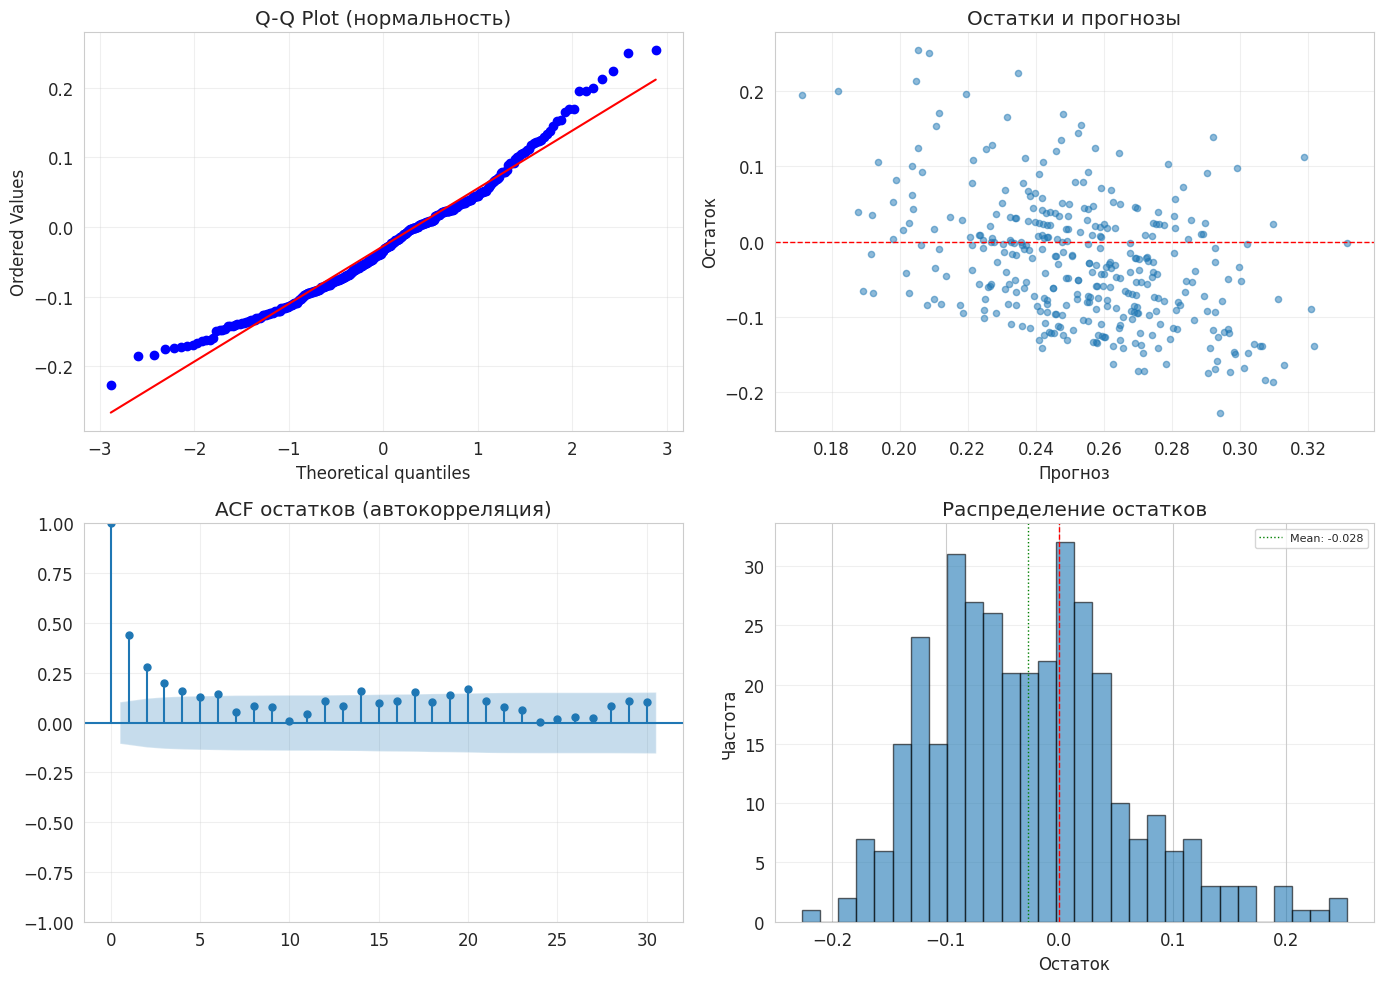

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Q-Q plot (проверка нормальности)
ax1 = axes[0, 0]
stats.probplot(residuals, dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot (нормальность)')
ax1.grid(True, alpha=0.3)

# 2. Остатки и прогнозы (гетероскедастичность)
ax2 = axes[0, 1]
ax2.scatter(best_pred, residuals, alpha=0.5, s=20)
ax2.axhline(0, color='red', linewidth=1, linestyle='--')
ax2.set_title('Остатки и прогнозы')
ax2.set_xlabel('Прогноз')
ax2.set_ylabel('Остаток')
ax2.grid(True, alpha=0.3)

# 3. ACF остатков (автокорреляция)
ax3 = axes[1, 0]
plot_acf(residuals, lags=30, ax=ax3, alpha=0.05)
ax3.set_title('ACF остатков (автокорреляция)')
ax3.grid(True, alpha=0.3)

# 4. Гистограмма остатков (распределение)
ax4 = axes[1, 1]
ax4.hist(residuals, bins=30, alpha=0.6, edgecolor='black')
ax4.axvline(0, color='red', linewidth=1, linestyle='--')
ax4.axvline(residuals.mean(), color='green', linewidth=1, linestyle=':', label=f'Mean: {residuals.mean():.3f}')
ax4.set_title('Распределение остатков')
ax4.set_xlabel('Остаток')
ax4.set_ylabel('Частота')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Проведём оценку важности признаков (топ-10):

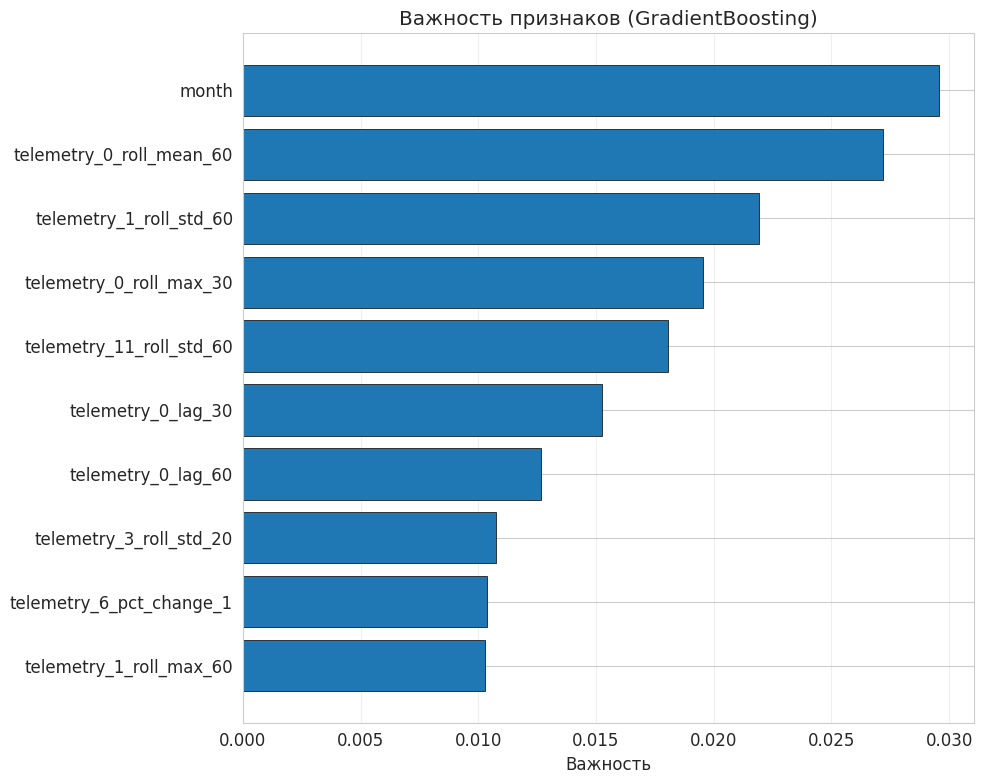

In [39]:
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif best_model_name == 'OLS':
    importances = np.abs(best_model.params[1:])
else:
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({
        'feature': X_train.columns if best_model_name != 'OLS' else selected_features_for_ols,
        'importance': importances
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    top = feat_imp.head(10).iloc[::-1]
    plt.barh(top['feature'], top['importance'], edgecolor='black', linewidth=0.5)
    plt.title(f'Важность признаков ({best_model_name})')
    plt.xlabel('Важность')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

Применим метод Permutation Importance:

In [41]:
from sklearn.inspection import permutation_importance


n_perm = min(100, len(X_test))
perm = permutation_importance(best_model, X_test.iloc[:n_perm], y_test.iloc[:n_perm],
                              n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)
perm_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

print(f"Топ-10 признаков:")
for _, row in perm_imp.head(10).iterrows():
    print(f"\t{row['feature']:45s} : {row['importance']:.4f}")

Топ-10 признаков:
	telemetry_8_lag_15                            : 0.0165
	day_of_week                                   : 0.0098
	telemetry_0_roll_min_30                       : 0.0094
	telemetry_5_roll_std_10                       : 0.0087
	telemetry_5_roll_std_30                       : 0.0082
	telemetry_2_pct_change_1                      : 0.0081
	telemetry_11_roll_std_20                      : 0.0079
	telemetry_3_roll_std_60                       : 0.0078
	telemetry_7_roll_std_20                       : 0.0075
	telemetry_3_lag_60                            : 0.0074


Проведём SHAP-анализ:

SHAP-анализ для GradientBoosting:


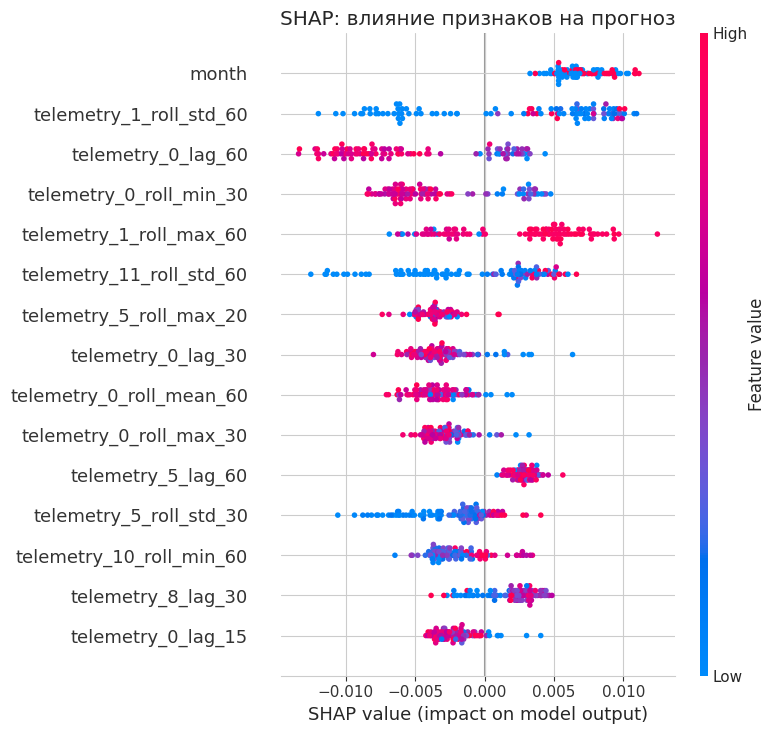

In [42]:
import shap


print(f"SHAP-анализ для {best_model_name}:")
X_shap = X_test.iloc[:min(100, len(X_test))]
shap_values = shap.TreeExplainer(best_model).shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title('SHAP: влияние признаков на прогноз')
plt.tight_layout()
plt.show()

### Интерпретация физических закономерностей:

Доминирование признаков, характеризующих стандартное отклонение параметров (**roll_std**), свидетельствует о том, что для процесса более важна стабильность технологического режима, чем абсолютные значения параметров. Иными словами, колебания температуры и давления в часовом интервале оказывают более существенное влияние на концентрацию продукта, чем их средние значения.

Присутствие среди наиболее значимых признаков лагов в диапазоне 30–60 минут подтверждает выраженную инерционность процесса обжига. Это указывает на то, что текущая концентрация определяется совокупным воздействием технологических условий, сформировавшихся в течение последнего часа, а не только параметрами в момент отбора пробы.

Наиболее информативные телеметрические каналы (0, 1, 3, 5, 11), предположительно, отражают параметры температурных зон и режимы подачи газа, что согласуется с физико-технологической природой процесса.

Таким образом, для повышения точности прогнозирования и эффективности управления качеством продукции целесообразно обеспечивать стабильность технологического режима печи, а также учитывать исторические телеметрические данные с глубиной не менее 60 минут.

## Общий вывод:

В ходе выполнения лабораторной работы был разработан полный пайплайн прогнозирования концентрации продукта обжига: от синхронизации разнородных источников данных с учётом технологической задержки в 11 минут до построения и валидации моделей машинного обучения.

Среди рассмотренных моделей наилучшее качество продемонстрировал **Gradient Boosting** (MAE = 0.071), превзойдя **OLS** и **Random Forest**, что дополнительно подтверждает нелинейный характер исследуемого технологического процесса. В то же время отрицательные значения R² на тестовой выборке указывают на необходимость дальнейшей оптимизации моделей, в частности подбора гиперпараметров и расширения пространства признаков.

Анализ важности признаков позволил выявить ряд существенных закономерностей: инерционность процесса (значимость признаков с окнами порядка 60 минут), высокую чувствительность к стабильности технологических параметров (доминирование признаков типа **roll_std**), а также наличие временных зависимостей, связанных с возможными сезонными или циклическими эффектами.

Полученные результаты позволяют сформулировать практические рекомендации, направленные на повышение качества продукции, включая поддержание стабильности технологического режима печи и использование исторических телеметрических данных для более точного прогнозирования концентрации продукта.